# Days on Lot Prediction — BMW Dealer Inventory (Feb 26, 2026 Snapshot)

This notebook builds a regression model to predict **how many days a vehicle sits on the dealer's lot**. The target variable is computed as:

$$\text{days\_on\_lot} = \text{2026-02-26} - \text{dealeractualarrivaldate}$$

We filter the data to only include vehicles with DAR status **"1-DEALER INVENTORY"** (vehicles currently sitting at the dealer).

### Key Differences from Feb 7 Snapshot
- Single enriched file (`invsearchvehicles-02262026.csv`) — no separate options/option-codes files
- Dataset is ~5.7× larger (3,750 vs 662 dealer-inventory vehicles)
- Options features replaced by `featurescount` and built-in pricing columns (`totalmsrp`, `basemsrp`, `saleprice`)

### Approach
1. **Load & filter** the raw inventory data
2. **Feature engineering** — extract meaningful features from vehicle specs, dates, pricing, and dealer info
3. **Random train/test split (85/15)** — stratified by days-on-lot quartile
4. **Ridge Regression (L2)** — provides feature importance via coefficient magnitudes
5. **Evaluation** — MAE, RMSE, R² on the held-out test set
6. **Feature importance** — analyze which factors most influence days on lot

## 1. Imports & Setup

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

DATA_FILE = "invsearchvehicles-02262026.csv"
SNAPSHOT_DATE = pd.Timestamp("2026-02-26")
SEED = 42

print("Setup complete.")

Setup complete.


## 2. Load Data & Compute Target

We load the single enriched inventory file for Feb 26, 2026.

We filter to vehicles with `darstatus == "1-DEALER INVENTORY"` — these are the vehicles physically at the dealer lot.

The target **`days_on_lot`** is computed by subtracting each vehicle's `dealeractualarrivaldate` from the snapshot date of **Feb 26, 2026**.

In [18]:
# Load main vehicle data
raw = pd.read_csv(DATA_FILE, low_memory=False)
print(f"Total vehicles in dataset: {len(raw):,}")

# Filter to dealer inventory only
df = raw[raw["darstatus"] == "1-DEALER INVENTORY"].copy()
print(f"Vehicles with '1-DEALER INVENTORY' status: {len(df):,}")

# Replace 'NULL' strings with actual NaN
df = df.replace("NULL", np.nan)

# Compute target: days_on_lot
df["dealeractualarrivaldate"] = pd.to_datetime(df["dealeractualarrivaldate"], format="mixed")
df["days_on_lot"] = (SNAPSHOT_DATE - df["dealeractualarrivaldate"]).dt.days

print(f"\nTarget variable (days_on_lot) summary:")
print(df["days_on_lot"].describe())

Total vehicles in dataset: 4,668
Vehicles with '1-DEALER INVENTORY' status: 3,750

Target variable (days_on_lot) summary:
count    3750.000000
mean      176.806400
std        97.659609
min         0.000000
25%        95.250000
50%       182.000000
75%       255.000000
max       380.000000
Name: days_on_lot, dtype: float64


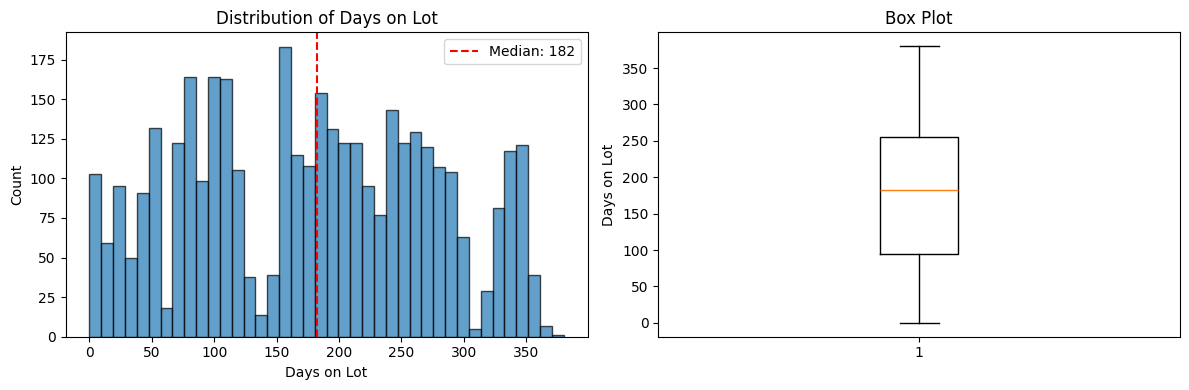

In [19]:
# Distribution of target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["days_on_lot"].dropna(), bins=40, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Days on Lot")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Days on Lot")
axes[0].axvline(df["days_on_lot"].median(), color="red", linestyle="--", label=f"Median: {df['days_on_lot'].median():.0f}")
axes[0].legend()

axes[1].boxplot(df["days_on_lot"].dropna(), vert=True)
axes[1].set_ylabel("Days on Lot")
axes[1].set_title("Box Plot")

plt.tight_layout()
plt.show()

## 3. Feature Engineering

We engineer features from multiple dimensions of the data:

### Vehicle Specs (Numeric)
- `horsepower`, `milespergallon`, `acceleration`, `grossweight`, `modelyear`, `environment` (emission class)
- `featurescount` — total count of features/options on the vehicle (built into this dataset)

### Pricing Features
- `totalmsrp` — full MSRP including options
- `basemsrp` — base MSRP before options
- `saleprice` — actual sale/sticker price at the dealer
- `msrp_premium` — derived: `totalmsrp - basemsrp` (dollar value of options added above base)

### Date-Derived Features
- `arrival_month`, `arrival_dow` (day of week) — capture seasonal/weekly arrival patterns
- `production_to_arrival_days` — transit time from production to dealer arrival
- `ship_to_arrival_days` — shipping duration
- `productionweek` — the ISO production week

### Categorical Features (One-Hot Encoded)
- `modeldescription` — X3 30, X5 40i, X5 50e, X5 M60i, X3 M50, X5 M, etc.
- `powertrain` — xDrive AWD, RWD, M xDrive, etc.
- `ordertype` — Priority Stock, Stock, Customer "Sold", etc.
- `exteriorgenericcolor`, `interiorgenericcolor` — color preferences affect lot time
- `dealerregion`, `dealermarket` — geographic effects
- `portofentry` — import port (affects arrival timing)
- `fueltype`, `hybridflag`, `sportsflag`, `stopsale`

In [20]:
# ---- Pricing-derived features ----
df["totalmsrp"] = pd.to_numeric(df["totalmsrp"], errors="coerce")
df["basemsrp"] = pd.to_numeric(df["basemsrp"], errors="coerce")
df["saleprice"] = pd.to_numeric(df["saleprice"], errors="coerce")
df["msrp_premium"] = df["totalmsrp"] - df["basemsrp"]

print("Pricing features:")
for col in ["totalmsrp", "basemsrp", "saleprice", "msrp_premium"]:
    print(f"  {col:20s}  mean={df[col].mean():>10,.0f}  non-null={df[col].notna().sum()}/{len(df)}")

Pricing features:
  totalmsrp             mean=    71,737  non-null=3750/3750
  basemsrp              mean=    62,405  non-null=3750/3750
  saleprice             mean=         0  non-null=3750/3750
  msrp_premium          mean=     9,332  non-null=3750/3750


In [21]:
# ---- Date-derived features ----

df["arrival_month"] = df["dealeractualarrivaldate"].dt.month
df["arrival_dow"] = df["dealeractualarrivaldate"].dt.dayofweek  # 0=Mon, 6=Sun

# Production-to-arrival transit time
df["actualproductiondate"] = pd.to_datetime(df["actualproductiondate"], format="mixed", errors="coerce")
df["production_to_arrival_days"] = (df["dealeractualarrivaldate"] - df["actualproductiondate"]).dt.days

# Ship-to-arrival time
df["vehicleshipdate"] = pd.to_datetime(df["vehicleshipdate"], format="mixed", errors="coerce")
df["ship_to_arrival_days"] = (df["dealeractualarrivaldate"] - df["vehicleshipdate"]).dt.days

# Clip negative transit times to 0 (data quality)
df["production_to_arrival_days"] = df["production_to_arrival_days"].clip(lower=0)
df["ship_to_arrival_days"] = df["ship_to_arrival_days"].clip(lower=0)

print("Date features engineered.")
print(f"  production_to_arrival_days: mean={df['production_to_arrival_days'].mean():.1f}, median={df['production_to_arrival_days'].median():.1f}")
print(f"  ship_to_arrival_days: mean={df['ship_to_arrival_days'].mean():.1f}, median={df['ship_to_arrival_days'].median():.1f}")

Date features engineered.
  production_to_arrival_days: mean=7.5, median=4.0
  ship_to_arrival_days: mean=6.4, median=3.0


In [22]:
# ---- Assemble feature matrix ----

# Numeric features
numeric_features = [
    "horsepower", "milespergallon", "acceleration", "grossweight",
    "modelyear", "environment", "productionweek",
    "arrival_month", "arrival_dow",
    "production_to_arrival_days", "ship_to_arrival_days",
    "featurescount", "totalmsrp", "basemsrp", "saleprice", "msrp_premium",
]

# Categorical features to one-hot encode
categorical_features = [
    "modeldescription", "powertrain", "ordertype",
    "exteriorgenericcolor", "interiorgenericcolor",
    "dealerregion", "dealermarket",
    "portofentry", "fueltype", "hybridflag",
    "sportsflag", "stopsale",
]

# Convert numeric columns
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing target
df = df.dropna(subset=["days_on_lot"])
print(f"Rows after dropping missing targets: {len(df):,}")

# Drop columns that are entirely null (can't be imputed)
null_pct = df[numeric_features].isna().mean()
drop_cols = null_pct[null_pct == 1.0].index.tolist()
if drop_cols:
    print(f"Dropping fully-null numeric columns: {drop_cols}")
    numeric_features = [c for c in numeric_features if c not in drop_cols]

# One-hot encode categoricals
df_encoded = pd.get_dummies(df[categorical_features], columns=categorical_features, drop_first=True, dtype=int)

# Combine all features (do NOT impute yet — imputation happens post-split to avoid leakage)
X = pd.concat([df[numeric_features].reset_index(drop=True), df_encoded.reset_index(drop=True)], axis=1)
y = df["days_on_lot"].reset_index(drop=True)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures ({len(X.columns)} total):")
for i, f in enumerate(X.columns):
    print(f"  {i+1:3d}. {f}")

Rows after dropping missing targets: 3,750
Dropping fully-null numeric columns: ['featurescount']
Feature matrix shape: (3750, 52)
Target shape: (3750,)

Features (52 total):
    1. horsepower
    2. milespergallon
    3. acceleration
    4. grossweight
    5. modelyear
    6. environment
    7. productionweek
    8. arrival_month
    9. arrival_dow
   10. production_to_arrival_days
   11. ship_to_arrival_days
   12. totalmsrp
   13. basemsrp
   14. saleprice
   15. msrp_premium
   16. modeldescription_X3 M50
   17. modeldescription_X5 40i
   18. modeldescription_X5 50e
   19. modeldescription_X5 M
   20. modeldescription_X5 M60i
   21. powertrain_Rear-wheel drive
   22. powertrain_xDrive all-wheel drive
   23. powertrain_xDrive, intelligent all-wheel drive
   24. ordertype_Customer "Sold"
   25. ordertype_DIRECT SHIPMENT
   26. ordertype_Non-priority Stock
   27. ordertype_Performance Center
   28. ordertype_Priority Stock
   29. ordertype_Stock
   30. ordertype_Subsidiary  Stock
   3

## 4. Train/Test Split (Stratified Random 85/15)

Since all vehicles in this snapshot have DAR status "1-DEALER INVENTORY", we use a **random 85/15 split stratified by days-on-lot quartile**. This ensures both sets reflect the full distribution of the target variable.

In [23]:
# Create stratification bins based on days_on_lot quartiles
strat_bins = pd.qcut(y, q=4, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=strat_bins
)

print(f"Training set: {len(X_train)} vehicles")
print(f"  Mean days on lot: {y_train.mean():.1f}")
print(f"  Std days on lot:  {y_train.std():.1f}")
print()
print(f"Test set: {len(X_test)} vehicles (15%)")
print(f"  Mean days on lot: {y_test.mean():.1f}")
print(f"  Std days on lot:  {y_test.std():.1f}")
print()
print("Distribution check (quartile proportions):")
for label, subset in [("Train", y_train), ("Test", y_test)]:
    q_counts = pd.qcut(subset, q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop").value_counts(normalize=True).sort_index()
    print(f"  {label}: {q_counts.to_dict()}")

Training set: 3187 vehicles
  Mean days on lot: 177.0
  Std days on lot:  97.7

Test set: 563 vehicles (15%)
  Mean days on lot: 175.5
  Std days on lot:  97.6

Distribution check (quartile proportions):
  Train: {'Q1': 0.2500784436774396, 'Q2': 0.25604016316284905, 'Q3': 0.24788202070913085, 'Q4': 0.24599937245058048}
  Test: {'Q1': 0.25044404973357015, 'Q2': 0.25044404973357015, 'Q3': 0.24866785079928952, 'Q4': 0.25044404973357015}


## 5. Ridge Regression (L2 Regularization)

We use **Ridge Regression** with L2 penalty. Features are standardized so coefficient magnitudes are directly comparable across features with different scales.

In [24]:
# Impute remaining NaNs using train medians only (avoids data leakage)
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Ridge Regression
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

print(f"Ridge model fitted with alpha=1.0")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Training R²: {ridge.score(X_train_scaled, y_train):.4f}")

Ridge model fitted with alpha=1.0
Number of features: 52
Training R²: 0.8373


## 6. Evaluation on Test Set

In [25]:
# Predict on test set
y_pred = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("TEST SET RESULTS (stratified random 15% holdout)")
print("=" * 50)
print(f"  MAE  : {mae:.2f} days")
print(f"  RMSE : {rmse:.2f} days")
print(f"  R²   : {r2:.4f}")
print(f"\n  Baseline (predict mean): MAE = {np.abs(y_test - y_train.mean()).mean():.2f} days")

TEST SET RESULTS (stratified random 15% holdout)
  MAE  : 32.46 days
  RMSE : 38.98 days
  R²   : 0.8401

  Baseline (predict mean): MAE = 83.03 days


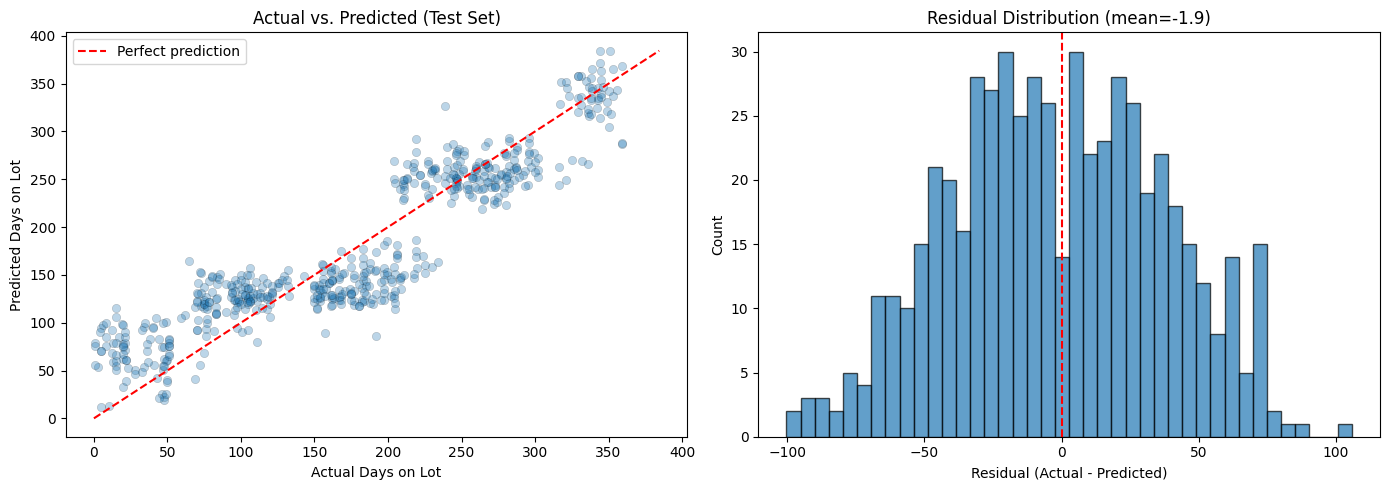

In [26]:
# Actual vs. Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, y_pred, alpha=0.3, edgecolors="k", linewidths=0.3)
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Days on Lot")
axes[0].set_ylabel("Predicted Days on Lot")
axes[0].set_title("Actual vs. Predicted (Test Set)")
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution (mean={residuals.mean():.1f})")

plt.tight_layout()
plt.show()

## 7. Feature Importance (Ridge Coefficients)

Because we standardized all features before fitting, the **absolute value of each Ridge coefficient** tells us how much that feature influences the prediction.

- **Positive coefficients** → the feature increases predicted days on lot (vehicle sits longer)
- **Negative coefficients** → the feature decreases predicted days on lot (vehicle moves faster)

In [27]:
# Feature importance from Ridge coefficients
importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": ridge.coef_,
    "abs_coefficient": np.abs(ridge.coef_),
}).sort_values("abs_coefficient", ascending=False)

print("Top 20 Most Important Features (by |coefficient|):")
print("=" * 65)
for i, row in importance.head(20).iterrows():
    direction = "+" if row["coefficient"] > 0 else "-"
    bar = "|" * int(row["abs_coefficient"] / importance["abs_coefficient"].max() * 30)
    print(f"  {direction} {row['feature']:45s} {row['coefficient']:>8.2f}  {bar}")

Top 20 Most Important Features (by |coefficient|):
  - basemsrp                                       -598.51  ||||||||||||||||||||||||||||||
  - totalmsrp                                      -486.43  ||||||||||||||||||||||||
  + horsepower                                      302.46  |||||||||||||||
  + grossweight                                     256.79  ||||||||||||
  + modeldescription_X5 M60i                        225.42  |||||||||||
  + modeldescription_X5 40i                         187.31  |||||||||
  + modeldescription_X5 M                           162.04  ||||||||
  + sportsflag_True                                 162.04  ||||||||
  - acceleration                                   -151.04  |||||||
  + msrp_premium                                    120.93  ||||||
  - milespergallon                                 -101.43  |||||
  - modeldescription_X5 50e                         -34.86  |
  - hybridflag_PHEV                                 -34.86  |
  - fueltype_X     

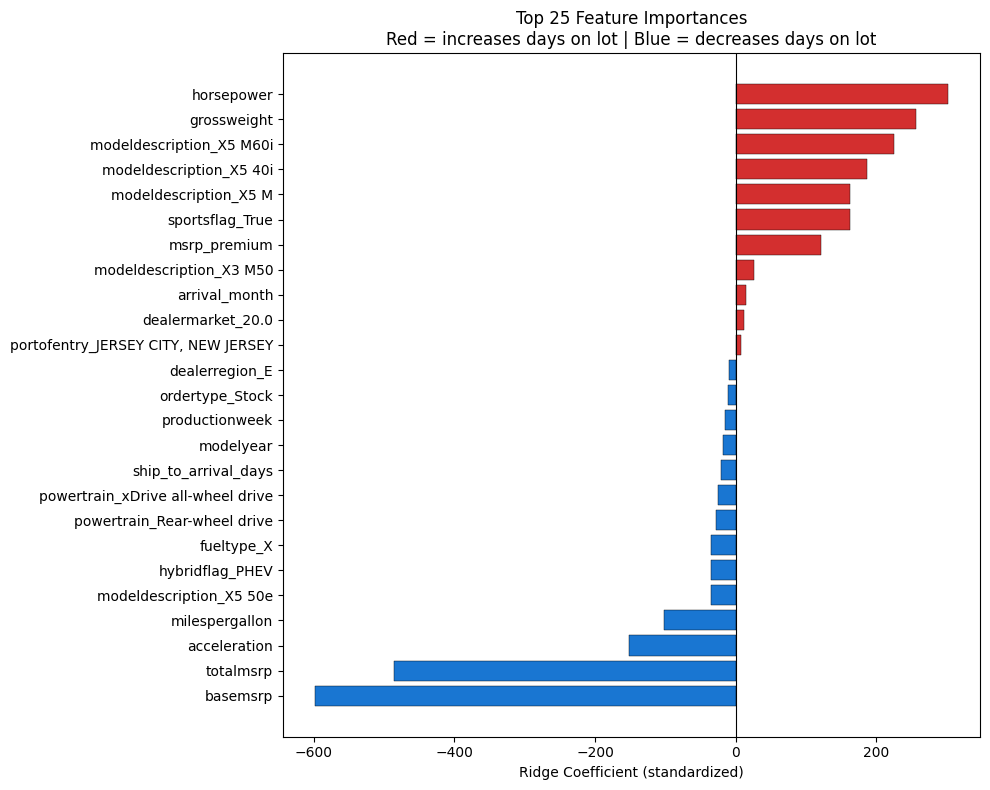

In [28]:
# Horizontal bar chart of top 25 features
top_n = 25
top_features = importance.head(top_n).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#d32f2f" if c > 0 else "#1976d2" for c in top_features["coefficient"]]
ax.barh(top_features["feature"], top_features["coefficient"], color=colors, edgecolor="black", linewidth=0.3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Ridge Coefficient (standardized)")
ax.set_title(f"Top {top_n} Feature Importances\nRed = increases days on lot | Blue = decreases days on lot")
plt.tight_layout()
plt.show()

In [29]:
# Full feature importance table
print("\nComplete Feature Importance Table:")
print(importance[["feature", "coefficient", "abs_coefficient"]].to_string(index=False))


Complete Feature Importance Table:
                                       feature  coefficient  abs_coefficient
                                      basemsrp  -598.514553       598.514553
                                     totalmsrp  -486.434319       486.434319
                                    horsepower   302.462080       302.462080
                                   grossweight   256.792312       256.792312
                      modeldescription_X5 M60i   225.423921       225.423921
                       modeldescription_X5 40i   187.310385       187.310385
                         modeldescription_X5 M   162.044801       162.044801
                               sportsflag_True   162.044801       162.044801
                                  acceleration  -151.038278       151.038278
                                  msrp_premium   120.927379       120.927379
                                milespergallon  -101.427382       101.427382
                       modeldescription_

## 8. Alpha Tuning (Optional)

Sweep over regularization strength to find the best balance between bias and variance.

 alpha  train_r2  test_r2  test_mae
  0.01  0.846167 0.852405 31.164859
  0.10  0.845994 0.851798 31.254968
  0.50  0.843153 0.847399 31.716455
  1.00  0.837344 0.840091 32.461728
  5.00  0.785798 0.782764 37.324182
 10.00  0.746988 0.741524 40.191707
 50.00  0.678003 0.669772 44.481098
100.00  0.663722 0.655167 45.296387
500.00  0.640691 0.631932 46.870732


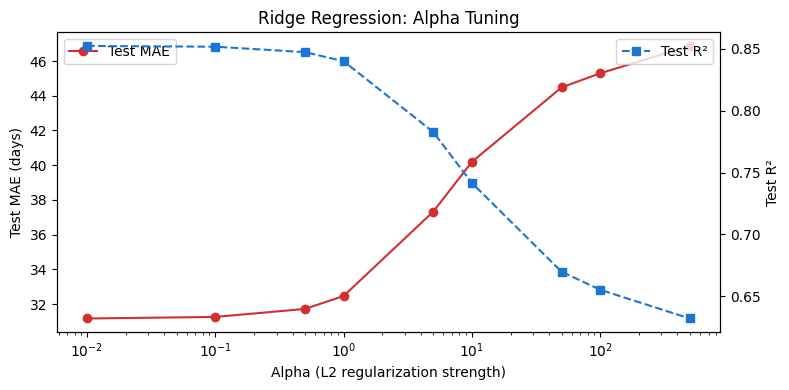


Best alpha: 0.01 (Test MAE: 31.16, Test R²: 0.8524)


In [30]:
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
results = []

for alpha in alphas:
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        "alpha": alpha,
        "train_r2": model.score(X_train_scaled, y_train),
        "test_r2": r2_score(y_test, pred),
        "test_mae": mean_absolute_error(y_test, pred),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(results_df["alpha"], results_df["test_mae"], "o-", color="#d32f2f", label="Test MAE")
ax1.set_xscale("log")
ax1.set_xlabel("Alpha (L2 regularization strength)")
ax1.set_ylabel("Test MAE (days)")
ax1.set_title("Ridge Regression: Alpha Tuning")

ax2 = ax1.twinx()
ax2.plot(results_df["alpha"], results_df["test_r2"], "s--", color="#1976d2", label="Test R²")
ax2.set_ylabel("Test R²")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

best = results_df.loc[results_df["test_mae"].idxmin()]
print(f"\nBest alpha: {best['alpha']} (Test MAE: {best['test_mae']:.2f}, Test R²: {best['test_r2']:.4f})")

## Summary

| Step | Detail |
|---|---|
| **Data** | Vehicles with DAR status "1-DEALER INVENTORY" (Feb 26, 2026 snapshot) |
| **Target** | `days_on_lot` = Feb 26, 2026 minus `dealeractualarrivaldate` |
| **Features** | Vehicle specs, date-derived, pricing (totalmsrp, basemsrp, saleprice, msrp_premium), categoricals |
| **Split** | Stratified random: 85% train / 15% test (stratified by target quartile) |
| **Imputation** | Median imputation fit on train set only (no leakage) |
| **Model** | Ridge Regression (L2 regularization) |
| **Feature Importance** | Derived from standardized Ridge coefficients |